# **Understanding Masking in NumPy using the QG Jet Dataset: Boolean Masking vs Masked Arrays**


> **Note**
>
> This notebook focuses on the practical implementation of Boolean Masking and NumPy Masked Arrays using the QG Jet Dataset.
>
> A detailed technical report containing the theoretical background, step-by-step code explanations, shape transformations, physics interpretation, and complete discussion of results is available in this repository:
>
> https://github.com/7hepratapyadav/numpy-masking-qg-jets/blob/main/NumPy_Masking_QG_Jets_Report.pdf


This notebook explores Boolean Masking and NumPy Masked Arrays using the QG Jet Dataset. The focus is on identifying padded particles, removing or masking them, and comparing both approaches at the jet level and dataset level.

In [1]:
import numpy as np
import numpy.ma as ma
import matplotlib.pyplot as plt

In [2]:
# Loading Dataset
data = np.load('QG_jets.npz')
print(f'Keys: {data.files}')

Keys: ['X', 'y']


In [3]:
X = data['X']
y = data['y']

print(f'X Shape: {X.shape}\ny Shape: {y.shape}')

X Shape: (100000, 139, 4)
y Shape: (100000,)


In [4]:
# Inspect first Jet (First Layer of the Dataset)
first_jet = X[0]
print(f'First jet: \n{first_jet}')

First jet: 
[[ 2.68769142e-01  3.56903171e-01  4.74138734e+00  2.20000000e+01]
 [ 1.60076377e-01 -2.55609533e-01  4.55022910e+00  2.20000000e+01]
 [ 1.14868731e+00 -6.24380156e-02  4.50385377e+00 -2.11000000e+02]
 [ 4.13159146e+00  1.73686350e-01  4.76622410e+00 -3.21000000e+02]
 [ 1.69599701e+00 -2.12177764e-01  4.79687162e+00 -2.11000000e+02]
 [ 2.19372581e+00 -5.24780791e-02  4.57559636e+00  2.20000000e+01]
 [ 1.61909680e+00 -6.76247614e-02  4.64561192e+00  2.20000000e+01]
 [ 6.59214883e+00  4.42691311e-02  4.76597141e+00  2.11000000e+02]
 [ 3.77096258e+00  4.22475280e-02  4.75473207e+00  3.21000000e+02]
 [ 1.34816345e+01 -2.80005472e-02  4.73543183e+00 -2.11000000e+02]
 [ 4.10794493e+00 -2.37648715e-02  4.75891312e+00  2.20000000e+01]
 [ 2.16455176e+01 -2.69973695e-02  4.75997450e+00  2.20000000e+01]
 [ 6.77551168e+00 -2.97549224e-02  4.76127746e+00  2.20000000e+01]
 [ 1.32550803e+01 -3.94389998e-02  4.74948328e+00  2.20000000e+01]
 [ 2.98350842e+00 -3.66033986e-02  4.74619579e+00 

In [5]:
# Analyzing Padding
# Count Zero rows.
padding_rows = np.sum((first_jet == 0).all(axis=1))
print(f'Padding rows: {padding_rows}')

# Count actual particles.
real_particles = np.sum((first_jet != 0).any(axis=1))
print(f'Real Particles: {real_particles}')

Padding rows: 121
Real Particles: 18


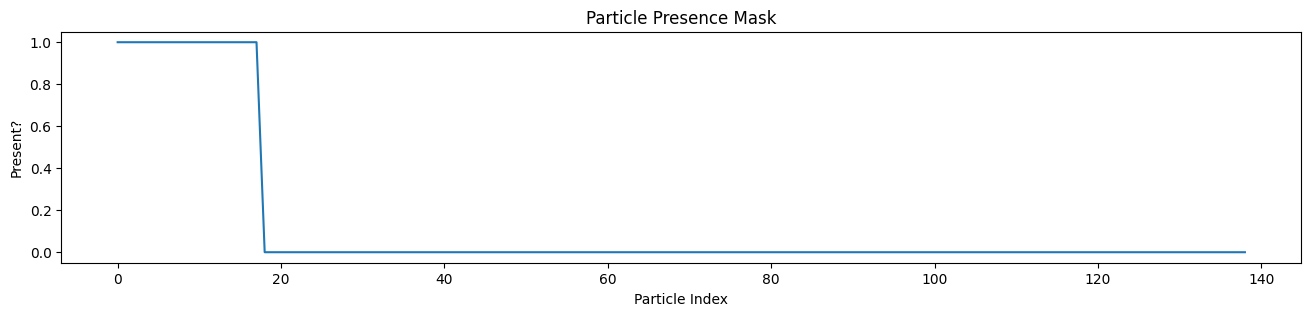

In [6]:
# Visualization
particle_mask = ((first_jet != 0).any(axis=1)).astype(int)
#print(particle_mask)

plt.figure(figsize=(16,3))
plt.plot(particle_mask)
plt.title("Particle Presence Mask")
plt.xlabel("Particle Index")
plt.ylabel("Present?")
plt.show()

*The plot shows that the first jet contains 18 real particles, while the remaining 121 particle positions correspond to padding.*

## Applying Boolean Masking In Only One Jet (First Jet)

In [7]:
# Step:- 1
comparison = first_jet != 0
print(f'Comparison Shape: {comparison.shape}\n')
print(comparison)

Comparison Shape: (139, 4)

[[ True  True  True  True]
 [ True  True  True  True]
 [ True  True  True  True]
 [ True  True  True  True]
 [ True  True  True  True]
 [ True  True  True  True]
 [ True  True  True  True]
 [ True  True  True  True]
 [ True  True  True  True]
 [ True  True  True  True]
 [ True  True  True  True]
 [ True  True  True  True]
 [ True  True  True  True]
 [ True  True  True  True]
 [ True  True  True  True]
 [ True  True  True  True]
 [ True  True  True  True]
 [ True  True  True  True]
 [False False False False]
 [False False False False]
 [False False False False]
 [False False False False]
 [False False False False]
 [False False False False]
 [False False False False]
 [False False False False]
 [False False False False]
 [False False False False]
 [False False False False]
 [False False False False]
 [False False False False]
 [False False False False]
 [False False False False]
 [False False False False]
 [False False False False]
 [False False False False]


In [8]:
# Step:- 2
mask = comparison.any(axis=1)
print(mask.shape)
print(mask)

(139,)
[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False]


In [9]:
# Create Boolean Mask (above two steps Combined)
mask = (first_jet != 0).any(axis=1)
print(f'Mask Shape: {mask.shape}\n')
print(mask)

Mask Shape: (139,)

[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False]


In [10]:
# Store only real particle by filtering padding
jet_filtered = first_jet[mask]

print(f'First jet Shape: {first_jet.shape}')
print(f'Filtered first jet shape: {jet_filtered.shape}')
print(f'Filtered first jet: \n{jet_filtered}')

First jet Shape: (139, 4)
Filtered first jet shape: (18, 4)
Filtered first jet: 
[[ 2.68769142e-01  3.56903171e-01  4.74138734e+00  2.20000000e+01]
 [ 1.60076377e-01 -2.55609533e-01  4.55022910e+00  2.20000000e+01]
 [ 1.14868731e+00 -6.24380156e-02  4.50385377e+00 -2.11000000e+02]
 [ 4.13159146e+00  1.73686350e-01  4.76622410e+00 -3.21000000e+02]
 [ 1.69599701e+00 -2.12177764e-01  4.79687162e+00 -2.11000000e+02]
 [ 2.19372581e+00 -5.24780791e-02  4.57559636e+00  2.20000000e+01]
 [ 1.61909680e+00 -6.76247614e-02  4.64561192e+00  2.20000000e+01]
 [ 6.59214883e+00  4.42691311e-02  4.76597141e+00  2.11000000e+02]
 [ 3.77096258e+00  4.22475280e-02  4.75473207e+00  3.21000000e+02]
 [ 1.34816345e+01 -2.80005472e-02  4.73543183e+00 -2.11000000e+02]
 [ 4.10794493e+00 -2.37648715e-02  4.75891312e+00  2.20000000e+01]
 [ 2.16455176e+01 -2.69973695e-02  4.75997450e+00  2.20000000e+01]
 [ 6.77551168e+00 -2.97549224e-02  4.76127746e+00  2.20000000e+01]
 [ 1.32550803e+01 -3.94389998e-02  4.74948328e+0

## Applying Masked Array In Only One Jet

In [11]:
# Create Masked Array.
first_masked_jet = ma.masked_where(first_jet == 0, first_jet)
print(f'first jet after applying masked array: \n{first_masked_jet}')

first jet after applying masked array: 
[[0.268769142268 0.35690317139 4.74138734068 22.0]
 [0.160076376923 -0.255609532536 4.55022910439 22.0]
 [1.1486873122 -0.0624380155973 4.50385376587 -211.0]
 [4.1315914562 0.173686350216 4.76622409945 -321.0]
 [1.69599701108 -0.212177763881 4.79687162303 -211.0]
 [2.1937258127 -0.0524780791366 4.57559636213 22.0]
 [1.61909679714 -0.0676247613978 4.6456119185 22.0]
 [6.59214883356 0.0442691311362 4.76597141041 211.0]
 [3.77096258048 0.0422475279636 4.75473206556 321.0]
 [13.4816344879 -0.0280005471822 4.7354318251 -211.0]
 [4.10794493413 -0.0237648714603 4.75891312271 22.0]
 [21.6455176275 -0.0269973695467 4.75997449703 22.0]
 [6.7755116767 -0.0297549223663 4.76127746469 22.0]
 [13.2550802949 -0.0394389998315 4.74948328171 22.0]
 [2.98350842322 -0.0366033986089 4.74619578812 22.0]
 [37.374386603 -0.0354428447702 4.75481318834 22.0]
 [335.399045773 -0.0325602518283 4.75085918258 22.0]
 [44.2135648615 -0.0332763049714 4.75431906552 22.0]
 [-- -- --

In [12]:
print(f'first jet shape: {first_jet.shape}')
print(f'first_masked_jet Shape: {first_masked_jet.shape}')

first jet shape: (139, 4)
first_masked_jet Shape: (139, 4)


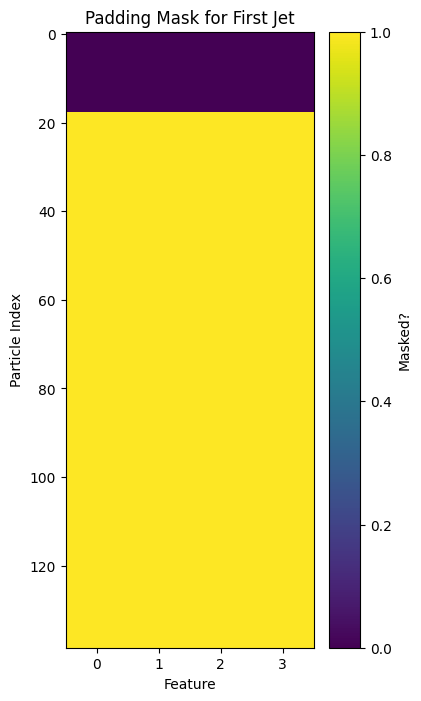

In [13]:
plt.figure(figsize=(4,8))
plt.imshow(first_masked_jet.mask, aspect='auto')
plt.title("Padding Mask for First Jet")
plt.xlabel("Feature")
plt.ylabel("Particle Index")
plt.colorbar(label="Masked?")
plt.show()

Each row corresponds to a particle position in the jet.

A value of False indicates a valid particle feature.

A value of True indicates that the corresponding feature has been masked because it belongs to a padded particle.

The transition from unmasked rows to masked rows reveals the point at which padding begins within the jet.

## Counting Particles with Both Methods

In [14]:
# Boolean Masking
# mask = (first_jet != 0).any(axis=1) already defined above in the Boolean Masking Section
particle_count_boolean = np.sum(mask)
print(f'Total number of Particles in first jet after applying Boolean Masking: {particle_count_boolean}')

Total number of Particles in first jet after applying Boolean Masking: 18


In [15]:
# Masked Array
particle_count_ma = np.sum(~(first_masked_jet.mask).all(axis=1))
print(f'Total number of Particle in first jet after applying Masked Array Masking: {particle_count_ma}')

Total number of Particle in first jet after applying Masked Array Masking: 18


## Mean pT Comparison

In [16]:
# Without Masking
print(f'Mean pT(Transverse momentum) of first jet without masking: {np.mean(first_jet[:,0])}')

Mean pT(Transverse momentum) of first jet without masking: 3.6030017985928127


In [17]:
# Boolean Masking
print(f'Mean pT(Transverse momentum) of first jet after applying Boolean Masking: {np.mean(jet_filtered[:,0])}')

Mean pT(Transverse momentum) of first jet after applying Boolean Masking: 27.823180555800054


In [18]:
# Masked Array
print(f'Mean pT(Transverse momentum) of first jet after applying Masked Array masking: {np.mean(first_masked_jet[:,0])}')

Mean pT(Transverse momentum) of first jet after applying Masked Array masking: 27.823180555800054


## Entire Dataset Analysis

### Boolean Masking

In [19]:
# Boolean Masking in Entire Dataset
''' 
complete_mask = (X != 0).any(axis=2)
particles_per_jet = np.sum(complete_mask, axis=1)
'''
particles_per_jet = ((X != 0).any(axis=2).sum(axis=1))
print(f'Shape of particle_per_jets array: {particles_per_jet.shape}')

Shape of particle_per_jets array: (100000,)


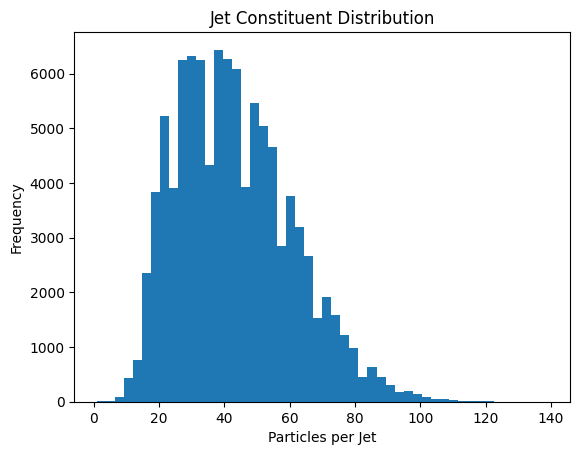

In [20]:
# Plot Distribution
plt.hist(particles_per_jet, bins=50)
plt.xlabel("Particles per Jet")
plt.ylabel("Frequency")
plt.title("Jet Constituent Distribution")
plt.show()

In [21]:
'''Since the shape of each jet may differ from each other so we cannot store all the jets in numpy array because numpy array do not allows to store
different shapes of array so we use python List to store each jet'''
filtered_jets = [jet[(jet != 0).any(axis=1)] for jet in X]
print(f'Shape of an jet whose index is 7165: {filtered_jets[7165].shape}')
print(f'Shape of an jet whose index is 0: {filtered_jets[0].shape}')

Shape of an jet whose index is 7165: (139, 4)
Shape of an jet whose index is 0: (18, 4)


In [22]:
len(filtered_jets)

100000

### Masked Array

In [23]:
# Masked Array in Entire Dataset
X_masked = ma.masked_where(X == 0, X)
particles_per_jet = np.sum((~(X_masked.mask).all(axis=2)), axis=1)
print(f'Shape of particles_per_jet array: {particles_per_jet.shape}')

Shape of particles_per_jet array: (100000,)


In [24]:
print(f'No. of particles of jet at index 7165: {particles_per_jet[7165]}')

No. of particles of jet at index 7165: 139


In [25]:
X_masked[:,:,0].shape

(100000, 139)

In [26]:
mean_pt_per_jet = np.mean(X_masked[:,:,0], axis=1)
print(f'Shape of the array containing mean of Transverse momentum of particles of each jets: {mean_pt_per_jet.shape}')

Shape of the array containing mean of Transverse momentum of particles of each jets: (100000,)


In [27]:
print(f'Mean pT(Transverse momentum) of first jet: {mean_pt_per_jet[0]}')

Mean pT(Transverse momentum) of first jet: 27.823180555800054


## Summary

In this notebook, two NumPy masking approaches were explored using the QG Jet Dataset.

- Boolean Masking removes padded particles from the array.
- Masked Arrays preserve the original tensor structure while hiding padded entries.
- Both methods correctly identify real particles and produce identical physics results when padding is handled properly.
- The choice between the two approaches depends on whether the original array structure needs to be preserved.

The analysis demonstrated that masking is essential when working with padded particle physics datasets, as padded entries can significantly distort statistical calculations.

## Boolean Masking vs Masked Arrays

| Property | Boolean Masking | Masked Arrays |
|-----------|-----------|-----------|
| Removes padded particles | Yes | No |
| Preserves original shape | No | Yes |
| Produces variable-length outputs | Yes | No |
| Suitable for particle-level analysis | Yes | Moderate |
| Suitable for dataset-wide statistics | Moderate | Excellent |
| Maintains fixed tensor structure | No | Yes |
| Automatically ignores padding in calculations | No | Yes |
| Easy to visualize valid particles | Yes | Yes |
| Best use case | Data selection | Statistical analysis |

## Final Takeaway

Boolean Masking and Masked Arrays solve the same padding problem in different ways.

Use Boolean Masking when padded particles should be physically removed from the dataset.

Use Masked Arrays when the original tensor structure must be preserved while ensuring that padded values do not influence calculations.